In [2]:
from pathlib import Path
import pandas as pd

project_features_dir = Path("Project_Features")

speech_file_paths = [
    file_path
    for file_path in project_features_dir.rglob("*.pkl")
    if "speech" in file_path.name.lower()
    and "vs" in file_path.name.lower()
]

speech_dataframes = []

for file_path in speech_file_paths:
    speech_dataframe = pd.read_pickle(file_path)
    speech_dataframe["source_file"] = file_path.name
    speech_dataframe["debate_name"] = file_path.stem.replace("_speech", "")
    speech_dataframes.append(speech_dataframe)

all_speech_data = pd.concat(speech_dataframes, ignore_index=True)

In [3]:
all_speech_data[["debate_name", "timestamp", "duration", "transcript", "text_embedding"]].head()

,debate_name,timestamp,duration,transcript,text_embedding
0,Gouveia_Melo_vs_Ventura_December_15,0.031,59.400,"na RTP notícias e na RTP internacional, André...","[1.932596, 0.25262952, 0.16940236, 0.11127561,..."
1,Gouveia_Melo_vs_Ventura_December_15,79.259,26.511,"E apesar disso, estou em primeiro. Se eu não ...","[1.7688934, 0.19344099, 0.6034472, -0.13823429..."
2,Gouveia_Melo_vs_Ventura_December_15,130.492,55.502,"Para mim são duas eleições diferentes, há uma...","[1.8612492, -0.059221525, 0.40128872, -0.32141..."
3,Gouveia_Melo_vs_Ventura_December_15,194.093,44.280,O meu discurso é Portugal. O meu discurso é d...,"[1.7889506, 0.30942598, 0.37129813, -0.0809669..."
4,Gouveia_Melo_vs_Ventura_December_15,238.373,33.581,como serão todos contra mim. Isso mostra a qu...,"[2.0364203, 0.16627851, 0.0123991445, 0.043327..."


In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer



transcript_column = "transcript"
embedding_column = "text_embedding"

common_phrase_patterns = [
    r"\bquer dizer\b",
    r"\bvou dizer\b",
    r"\bneste momento\b",
    r"\bboa noite\b",
    r"\btoda a gente\b",
    r"\bpresidente da república\b",
    r"\bpresidente republica\b",
    r"\bprimeiro ministro\b",
]

portuguese_stopwords = [
    'a','ao','aos','aquela','aquelas','aquele','aqueles','aquilo','as','até',
    'com','como','da','das','de','dela','delas','dele','deles','depois','do',
    'dos','e','é','ela','elas','ele','eles','em','entre','era','essa','essas',
    'esse','esses','esta','estas','este','estes','eu','foi','foram','há',
    'isso','isto','já','lhe','lhes','me','mais','mas','me','mesmo','meu','meus',
    'minha','minhas','muito','na','não','nas','nem','no','nos','nós','nossa',
    'nossas','nosso','nossos','num','numa','o','os','ou','para','pela','pelas',
    'pelo','pelos','por','qual','quando','que','se','sem','ser','seu','seus',
    'só','sua','suas','também','te','tem','têm','tinha','todo','todos','tu',
    'um','uma','uns','umas','você','vós','à','às','é','tvi','rtp','telejornal',]



def clean_transcript_text(text):
    if not isinstance(text, str):
        return ""

    cleaned_text = text.lower()

    for pattern in common_phrase_patterns:
        cleaned_text = re.sub(pattern, " ", cleaned_text)

    cleaned_text = re.sub(r"[^a-záàâãéêíóôõúç\s]", " ", cleaned_text)
    cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

    return cleaned_text



def create_embedding_matrix(dataframe, embedding_column):
    valid_rows = dataframe[dataframe[embedding_column].apply(lambda value: isinstance(value, np.ndarray))].copy()

    embedding_matrix = np.vstack(valid_rows[embedding_column].to_numpy())

    return valid_rows.reset_index(drop=True), embedding_matrix


topic_data, text_embedding_matrix = create_embedding_matrix(all_speech_data, embedding_column)

topic_data["clean_transcript"] = topic_data[transcript_column].apply(clean_transcript_text)

print("Rows with usable embeddings:", len(topic_data))
print("Embedding matrix shape:", text_embedding_matrix.shape)

Rows with usable embeddings: 843
Embedding matrix shape: (843, 4096)


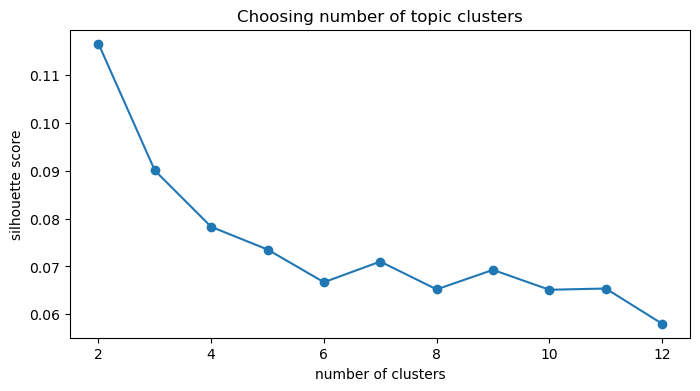

In [5]:

normalized_embeddings = normalize(text_embedding_matrix)

pca_model_for_clustering = PCA(n_components=50, random_state=0)
reduced_embeddings = pca_model_for_clustering.fit_transform(normalized_embeddings)

cluster_options = range(2, 13)
silhouette_scores = []

for number_of_clusters in cluster_options:
    kmeans_model = KMeans(n_clusters=number_of_clusters, random_state=0, n_init=20)
    cluster_labels = kmeans_model.fit_predict(reduced_embeddings)

    score = silhouette_score(reduced_embeddings, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(list(cluster_options), silhouette_scores, marker="o")
plt.xlabel("number of clusters")
plt.ylabel("silhouette score")
plt.title("Choosing number of topic clusters")
plt.show()

In [ ]:


number_of_topic_clusters = 3 

topic_cluster_model = KMeans(
    n_clusters=number_of_topic_clusters,
    random_state=0,
    n_init=20
)

topic_data["topic_cluster"] = topic_cluster_model.fit_predict(reduced_embeddings)

In [ ]:
# Gett topic keywords froom ttranscripts

def print_cluster_keywords_and_examples(topic_data, number_of_examples=5):
    for topic_cluster in sorted(topic_data["topic_cluster"].unique()):
        cluster_rows = topic_data[topic_data["topic_cluster"] == topic_cluster]
        cluster_texts = cluster_rows["clean_transcript"].dropna()

        vectorizer = TfidfVectorizer(ngram_range=(1, 3),stop_words=portuguese_stopwords, max_features=20,min_df=2)

        try:
            tfidf_matrix = vectorizer.fit_transform(cluster_texts)
            feature_names = vectorizer.get_feature_names_out()
            average_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

            top_indices = average_scores.argsort()[::-1][:15]
            top_terms = [feature_names[index] for index in top_indices]

        except ValueError:
            top_terms = []

        print("\n" + "=" * 80)
        print(f"TOPIC CLUSTER {topic_cluster}")
        print("Number of segments:", len(cluster_rows))
        print("Top terms:", top_terms)

        print("\nExample transcripts:")
        for transcript in cluster_rows[transcript_column].dropna().head(number_of_examples):
            print("-", transcript[:300])


print_cluster_keywords_and_examples(topic_data)


TOPIC CLUSTER 0
Number of segments: 282
Top terms: ['porque', 'são', 'está', 'ter', 'país', 'acho', 'pessoas', 'temos', 'portugal', 'fazer', 'portanto', 'economia', 'governo', 'seja', 'saúde']

Example transcripts:
-  que tem uma grande inclinação à direita, acordando com a esterema direita. E para quem há vezes fica muito paralhado com os termos do que significa, tem uma grande facilidade de desprezar quem vive de seu trabalho. É a única coisa que se usicam, por exemplo, os altrações ao código de trabalho que q
-  ter uma presidência da República que ajuda a equilibrar o quadro das instituições democráticas e que fala das crises que o país atravessa. O país não precisa de jovens mais precários, precisa seguramente de melhor emprego, com melhor salário, o país precisa de ultrapassar a escrisis habitação, escr
-  Eu acho que o projeto europeu vai sendo desenhato com vozes divergentes. A unidade europeia não existe, ou seja, não é uma coisa garantida, não existe, é uma disputa política,

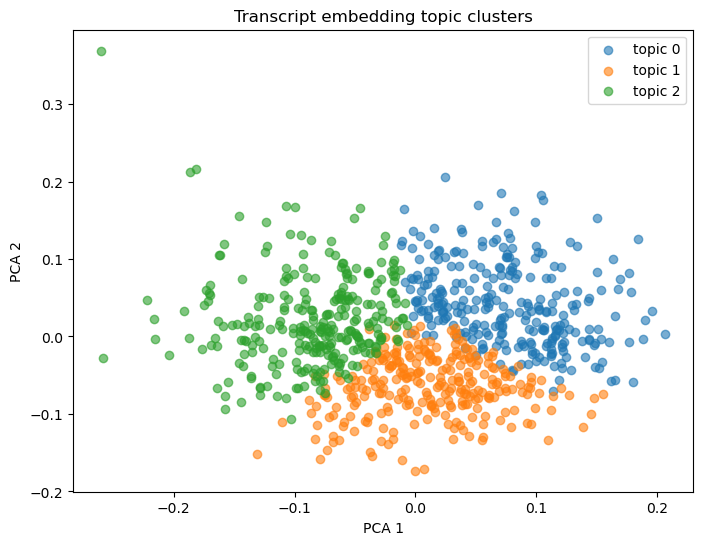

In [ ]:

pca_model_for_plot = PCA(n_components=2, random_state=0)
plot_coordinates = pca_model_for_plot.fit_transform(reduced_embeddings)

topic_data["topic_pca_1"] = plot_coordinates[:, 0]
topic_data["topic_pca_2"] = plot_coordinates[:, 1]

plt.figure(figsize=(8, 6))

for topic_cluster in sorted(topic_data["topic_cluster"].unique()):
    cluster_rows = topic_data[topic_data["topic_cluster"] == topic_cluster]
    plt.scatter(
        cluster_rows["topic_pca_1"],
        cluster_rows["topic_pca_2"],
        label=f"topic {topic_cluster}",
        alpha=0.6
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Transcript embedding topic clusters")
plt.legend()
plt.show()

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

portuguese_stopwords = [
    'a','ao','aos','aquela','aquelas','aquele','aqueles','aquilo','as','até',
    'com','como','da','das','de','dela','delas','dele','deles','depois','do',
    'dos','e','é','ela','elas','ele','eles','em','entre','era','essa','essas',
    'esse','esses','esta','estas','este','estes','eu','foi','foram','há',
    'isso','isto','já','lhe','lhes','me','mais','mas','me','mesmo','meu','meus',
    'minha','minhas','muito','na','não','nas','nem','no','nos','nós','nossa',
    'nossas','nosso','nossos','num','numa','o','os','ou','para','pela','pelas',
    'pelo','pelos','por','qual','quando','que','se','sem','ser','seu','seus',
    'só','sua','suas','também','te','tem','têm','tinha','todo','todos','tu',
    'um','uma','uns','umas','você','vós','à','às','é','tvi','rtp','telejornal',]

for cluster in sorted(topic_data["topic_cluster"].unique()):
    texts = topic_data[topic_data["topic_cluster"] == cluster]["clean_transcript"].dropna()

    vectorizer = TfidfVectorizer(
        ngram_range=(2, 3),      # only bigrams/trigrams
        stop_words=portuguese_stopwords,
        min_df=2,
        max_df=0.7,
        max_features=25
    )

    tfidf = vectorizer.fit_transform(texts)
    scores = np.asarray(tfidf.mean(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()

    print("\nTOPIC", cluster)
    print(terms[scores.argsort()[::-1][:20]])




TOPIC 0
['ponto vista' 'união europeia' 'presente república' 'muitas vezes'
 'direitos trabalhadores' 'porque acho' 'cima mesa' 'cada vez'
 'presidente república' 'país precisa' 'ter economia' 'pacote laboral'
 'acho importante' 'mil milhões' 'está aqui' 'nacional saúde'
 'milhões euros' 'serviço nacional' 'greve geral' 'assembleia república']

TOPIC 1
['união europeia' 'assembleia república' 'ponto vista' 'cima mesa'
 'estados unidos' 'andré ventura' 'segunda volta' 'estamos falar'
 'ter sido' 'catarina martins' 'bem vindos' 'diz respeito' 'frente frente'
 'presidente república' 'partido socialista' 'revisão constitucional'
 'marcos mendes' 'antónio felipe' 'tribunal constitucional'
 'precisamos ter']

TOPIC 2
['união europeia' 'presente república' 'segunda volta' 'outra coisa'
 'alguma coisa' 'senhor está' 'está aqui' 'vou fazer' 'quero dizer'
 'partido socialista' 'dizer coisa' 'vai ter' 'jorge pinto' 'quero saber'
 'sou candidato' 'andré ventura' 'vou dar' 'catarina martins'
 'blo

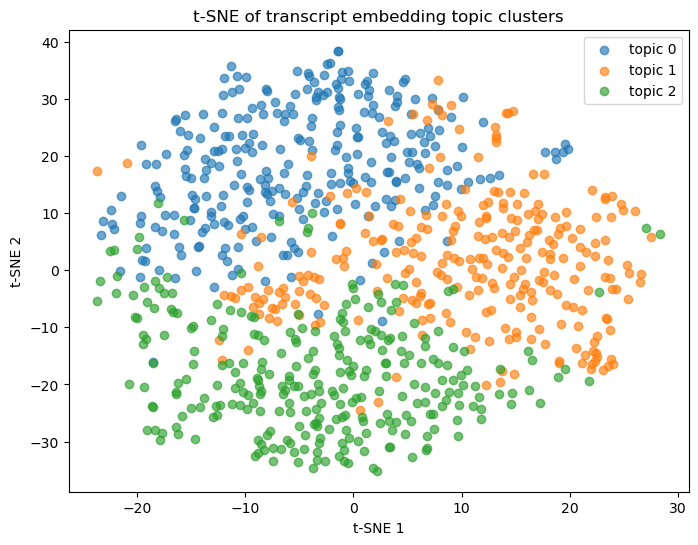

In [ ]:
# t-SNE plot of topic clusters

from sklearn.manifold import TSNE

perplexity_value = min(30, max(5, (len(topic_data) - 1) // 3))

tsne_model = TSNE(
    n_components=2,
    perplexity=perplexity_value,
    learning_rate="auto",
    init="pca",
    random_state=0,
)

tsne_coordinates = tsne_model.fit_transform(reduced_embeddings)

topic_data["topic_tsne_1"] = tsne_coordinates[:, 0]
topic_data["topic_tsne_2"] = tsne_coordinates[:, 1]

plt.figure(figsize=(8, 6))

for topic_cluster in sorted(topic_data["topic_cluster"].unique()):
    cluster_rows = topic_data[topic_data["topic_cluster"] == topic_cluster]
    plt.scatter(
        cluster_rows["topic_tsne_1"],
        cluster_rows["topic_tsne_2"],
        label=f"topic {topic_cluster}",
        alpha=0.65,
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of transcript embedding topic clusters")
plt.legend()
plt.show()


<Figure size 1200x500 with 0 Axes>

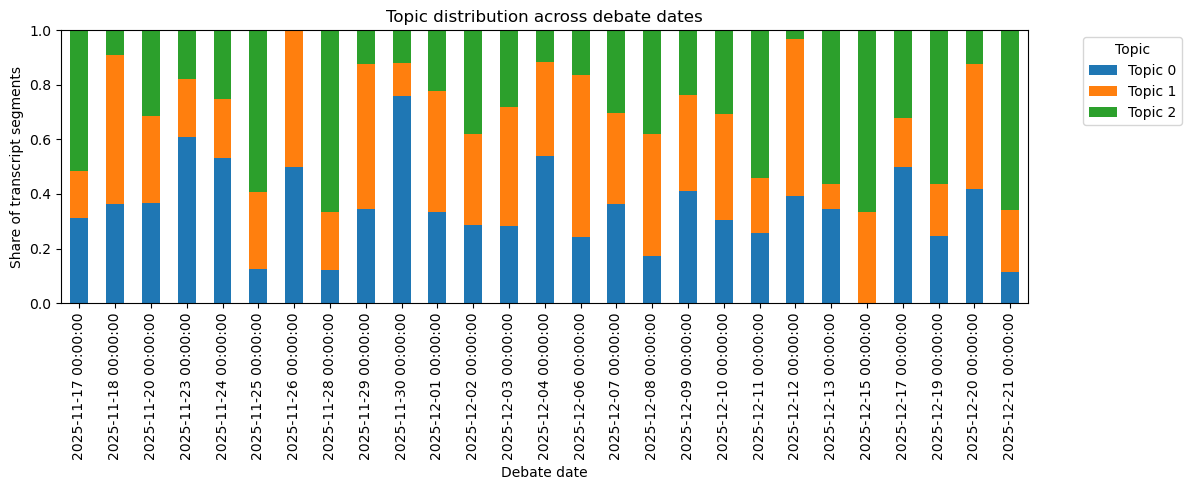

topic_cluster,Topic 0,Topic 1,Topic 2
debate_date,,,
2025-11-17,31.0,17.2,51.7
2025-11-18,36.4,54.5,9.1
2025-11-20,36.8,31.6,31.6
2025-11-23,60.7,21.4,17.9
2025-11-24,53.1,21.9,25.0
2025-11-25,12.5,28.1,59.4
2025-11-26,50.0,50.0,0.0
2025-11-28,12.1,21.2,66.7
2025-11-29,34.4,53.1,12.5


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt


topic_names = {
    0: "Topic 0",
    1: "Topic 1",
    2: "Topic 2"
}

month_name_to_number = {
    "November": 11,
    "December": 12,
    "January": 1
}


def extract_debate_date(debate_name):
    """
    Extracts date from names like:
    Cotrim_Figueiredo_vs_Filipe_November_30_audio
    Cotrim_Figueiredo_vs_Filipe_November_30_speech
    """
    debate_name_as_text = str(debate_name)

    date_match = re.search(
        r"(November|December|January)_(\d{1,2})",
        debate_name_as_text
    )

    if date_match is None:
        return pd.NaT

    month_name = date_match.group(1)
    day_number = int(date_match.group(2))
    month_number = month_name_to_number[month_name]

    if month_name in ["November", "December"]:
        year_number = 2025
    else:
        year_number = 2026

    return pd.Timestamp(
        year=year_number,
        month=month_number,
        day=day_number
    )


# wee add debate date
topic_data = topic_data.copy()
topic_data["debate_date"] = topic_data["debate_name"].apply(extract_debate_date)

# Remove rows where date could not be extracted
topic_data_with_dates = topic_data.dropna(subset=["debate_date"]).copy()

# Count topic segments per debate date
topic_counts_by_date = (
    topic_data_with_dates
    .groupby(["debate_date", "topic_cluster"])
    .size()
    .reset_index(name="segment_count")
)

# Convert counts to shares per date
topic_counts_by_date["topic_share"] = (
    topic_counts_by_date["segment_count"] /
    topic_counts_by_date.groupby("debate_date")["segment_count"].transform("sum")
)

# Pivot to table format for plotting
topic_share_table = topic_counts_by_date.pivot(
    index="debate_date",
    columns="topic_cluster",
    values="topic_share"
).fillna(0)

# Rename columns if topic_names are provided
topic_share_table = topic_share_table.rename(columns=topic_names)

# Sort by date
topic_share_table = topic_share_table.sort_index()

plt.figure(figsize=(12, 5))

topic_share_table.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5)
)

plt.ylabel("Share of transcript segments")
plt.xlabel("Debate date")
plt.title("Topic distribution across debate dates")
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Optional: print table as percentages
topic_share_percent_table = (topic_share_table * 100).round(1)
display(topic_share_percent_table)

we have some identification of the topics but it comes out just really unclear, as we can see in the viusalization, so really what we need to do is 

KMeans topic clusters vs spectral topic clusters:


spectral_topic_cluster,0,1,2
topic_cluster,,,
0,14,265,3
1,29,57,191
2,262,4,18


Spectral topic cluster sizes:


,rows
spectral_topic_cluster,
0,305
1,326
2,212


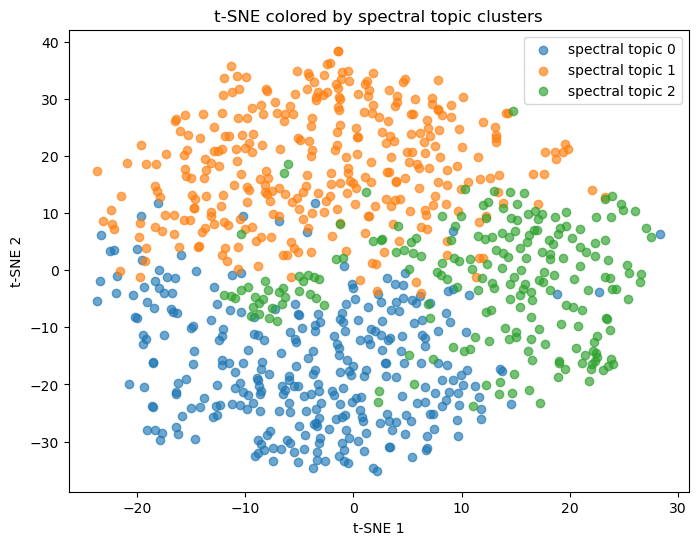

In [ ]:
# Spectral clustering comparison 

from sklearn.cluster import SpectralClustering

spectral_model = SpectralClustering(
    n_clusters=number_of_topic_clusters,
    affinity="nearest_neighbors",
    n_neighbors=15,
    assign_labels="kmeans",
    random_state=0,
)

topic_data["spectral_topic_cluster"] = spectral_model.fit_predict(reduced_embeddings)

print("KMeans topic clusters vs spectral topic clusters:")
display(pd.crosstab(topic_data["topic_cluster"], topic_data["spectral_topic_cluster"]))

print("Spectral topic cluster sizes:")
display(topic_data["spectral_topic_cluster"].value_counts().sort_index().to_frame("rows"))

plt.figure(figsize=(8, 6))

for spectral_topic_cluster in sorted(topic_data["spectral_topic_cluster"].unique()):
    cluster_rows = topic_data[topic_data["spectral_topic_cluster"] == spectral_topic_cluster]
    plt.scatter(
        cluster_rows["topic_tsne_1"],
        cluster_rows["topic_tsne_2"],
        label=f"spectral topic {spectral_topic_cluster}",
        alpha=0.65,
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE colored by spectral topic clusters")
plt.legend()
plt.show()

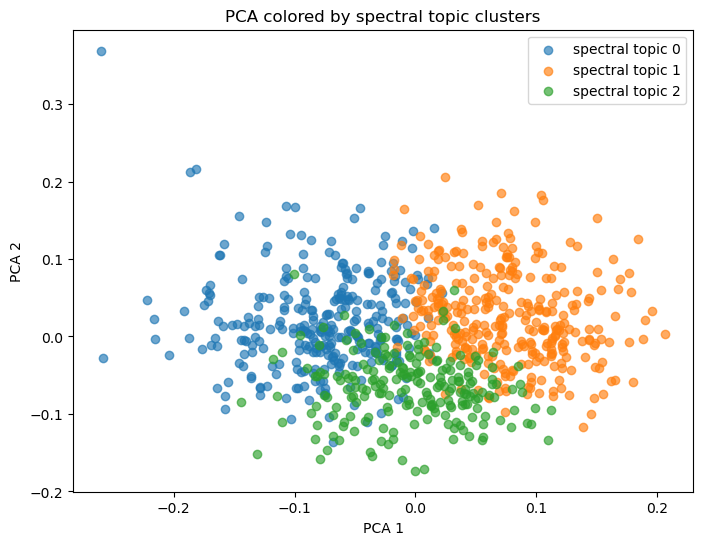

In [13]:


# Same PCA coordinates as above, but colored by spectral labels.
plt.figure(figsize=(8, 6))

for spectral_topic_cluster in sorted(topic_data["spectral_topic_cluster"].unique()):
    cluster_rows = topic_data[topic_data["spectral_topic_cluster"] == spectral_topic_cluster]
    plt.scatter(
        cluster_rows["topic_pca_1"],
        cluster_rows["topic_pca_2"],
        label=f"spectral topic {spectral_topic_cluster}",
        alpha=0.65,
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA colored by spectral topic clusters")
plt.legend()
plt.show()

In [14]:
for cluster in sorted(topic_data["spectral_topic_cluster"].unique()):
    texts = topic_data.loc[
        topic_data["spectral_topic_cluster"] == cluster,
        "clean_transcript"
    ].dropna()

    vectorizer = TfidfVectorizer(
        ngram_range=(2, 3),
        stop_words=portuguese_stopwords,
        min_df=2,
        max_df=0.7,
        max_features=25,
    )

    tfidf = vectorizer.fit_transform(texts)
    scores = np.asarray(tfidf.mean(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()

    print("\nSPECTRAL TOPIC", cluster)
    print(terms[scores.argsort()[::-1][:15]])


SPECTRAL TOPIC 0
['união europeia' 'está aqui' 'estados unidos' 'quero dizer' 'senhor está'
 'presente república' 'partido socialista' 'segunda volta' 'quem trabalha'
 'dizer coisa' 'sou candidato' 'vou dar' 'faz sentido' 'andré ventura'
 'vai ter']

SPECTRAL TOPIC 1
['ponto vista' 'direitos trabalhadores' 'união europeia' 'cima mesa'
 'presente república' 'estamos falar' 'muitas vezes'
 'presidente república' 'cada vez' 'país precisa' 'temos ter' 'pode fazer'
 'mil milhões' 'acho importante' 'ministério público']

SPECTRAL TOPIC 2
['união europeia' 'segunda volta' 'assembleia república' 'estados unidos'
 'andré ventura' 'jorge pinto' 'bem vindos' 'catarina martins'
 'diz respeito' 'pacote laboral' 'marcos mendes' 'frente frente'
 'ponto vista' 'cima mesa' 'sistema político']


In [15]:
topic_data["spectral_topic_cluster"].value_counts()

spectral_topic_cluster
1    326
0    305
2    212
Name: count, dtype: int64

In [16]:
topic_data["topic_cluster"].value_counts()

topic_cluster
2    284
0    282
1    277
Name: count, dtype: int64

In [17]:
from sklearn.metrics import silhouette_score
silhouette_score(reduced_embeddings, topic_data["topic_cluster"])

0.09004136919975281

In [18]:
silhouette_score(reduced_embeddings, topic_data["spectral_topic_cluster"])

0.08636512607336044

In [ ]:
# Debate-level topic summary for sending to Diego to compare with newscasts, that iss for does newcast affect debate topics? 
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

month_name_to_number = {"November": 11, "December": 12, "January": 1}


def extract_debate_date(debate_name):
    date_match = re.search(r"(November|December|January)_(\d{1,2})", str(debate_name))
    if date_match is None:
        return pd.NaT

    month_name = date_match.group(1)
    year_number = 2025 if month_name in ["November", "December"] else 2026
    return pd.Timestamp(
        year=year_number,
        month=month_name_to_number[month_name],
        day=int(date_match.group(2)),
    )


def get_top_terms(tfidf_row, feature_names, number_of_terms=8):
    top_indices = np.asarray(tfidf_row).ravel().argsort()[::-1][:number_of_terms]
    return ", ".join(feature_names[top_indices])


debate_topic_data = topic_data.copy()
debate_topic_data["debate_date"] = debate_topic_data["debate_name"].apply(extract_debate_date)
debate_topic_data = debate_topic_data.dropna(subset=["debate_date", "clean_transcript"])

debate_documents = (
    debate_topic_data.groupby(["debate_date", "debate_name"], as_index=False)
    .agg(
        transcript_segments=("clean_transcript", "size"),
        full_transcript=("clean_transcript", " ".join),
    )
    .sort_values(["debate_date", "debate_name"])
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    stop_words=portuguese_stopwords,
    min_df=1,
    max_df=0.85,
    max_features=300,
)

tfidf_matrix = vectorizer.fit_transform(debate_documents["full_transcript"])
feature_names = vectorizer.get_feature_names_out()

debate_documents["top_terms"] = [
    get_top_terms(tfidf_matrix[row_index].toarray(), feature_names)
    for row_index in range(tfidf_matrix.shape[0])
]

topic_counts = (
    debate_topic_data.groupby(["debate_name", "topic_cluster"])
    .size()
    .reset_index(name="topic_segments")
)
topic_counts["topic_share"] = (
    topic_counts["topic_segments"]
    / topic_counts.groupby("debate_name")["topic_segments"].transform("sum")
)
dominant_topics = (
    topic_counts.sort_values(["debate_name", "topic_segments"], ascending=[True, False])
    .drop_duplicates("debate_name")
    .rename(
        columns={
            "topic_cluster": "dominant_topic_cluster",
            "topic_share": "dominant_topic_share",
        }
    )
)

debate_topic_summary = debate_documents.merge(dominant_topics[["debate_name", "dominant_topic_cluster", "dominant_topic_share"]],
                                               on="debate_name", how="left",)

debate_topic_summary["dominant_topic_share"] = (debate_topic_summary["dominant_topic_share"] * 100).round(1)

output_path = Path("../cleaned_data/debate_topic_summary_timeline_for_diego")
debate_topic_summary.to_pickle(output_path.with_suffix(".pkl"))
debate_topic_summary.to_csv(output_path.with_suffix(".csv"), index=False)



debate_topic_summary[["debate_date", "debate_name", "transcript_segments", "dominant_topic_cluster", "dominant_topic_share", "top_terms",]]



,debate_date,debate_name,transcript_segments,dominant_topic_cluster,dominant_topic_share,top_terms
0,2025-11-17,Ventura_vs_Seguro_November_17,29,2,51.7,"partido, partido socialista, socialista, senho..."
1,2025-11-18,Filipe_vs_Marques_Mendes_November_18,33,1,54.5,"antónio, creio, felipe, trabalhadores, posição..."
2,2025-11-20,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,19,0,36.8,"defesa, qualquer, justiça, apoio, dia, nenhum,..."
3,2025-11-23,Martins_vs_Gouveia_Melo_November_23,28,0,60.7,"salário, horas, aliás, economia, defender, for..."
4,2025-11-24,Pinto_vs_Cotrim_Figueiredo_November_24,32,0,53.1,"joão, sns, senhor, jorge, problemas, corrupção..."
5,2025-11-25,Ventura_vs_Marques_Mendes_November_25,32,2,59.4,"senhor, corrupção, candidato, combate, luís, j..."
6,2025-11-26,Pinto_vs_Gouveia_Melo_November_26,24,0,50.0,"precisamente, portugueses, podemos, verdade, p..."
7,2025-11-28,Martins_vs_Ventura_November_28,33,2,66.7,"catarina, martins, mulheres, leis, estava, sab..."
8,2025-11-29,Pinto_vs_Marques_Mendes_November_29,32,1,53.1,"corrupção, revisão, constitucional, estabilida..."
9,2025-11-30,Cotrim_Figueiredo_vs_Filipe_November_30,33,0,75.8,"sns, felipe, pessoa, política, reforma, mil, s..."
